#### *June 23rd, 2025*

In [1]:
import os
import pandas as pd
import torch
import logging
import hashlib
import tempfile
import zipfile
import requests
from tqdm import tqdm
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids

In [2]:
URL = "https://bossdb-open-data.s3.amazonaws.com/iarpa_microns/minnie/functional_data/foundation_model/foundational_model_weights_and_metadata_v1.zip"
MD5 = "58fcac4b31ad2902c81e339432cec787" #verified downloaded model matches

logger = logging.getLogger("fnn.microns")
logger.addHandler(logging.StreamHandler())


def download(url, file_path, chunk_size=8192, verbose=True):
    """
    Parameters
    ----------
    url : str
        source url
    file_path : os.PathLike
        destination file path
    chunk_size : int
        size of the chunks (in bytes) to read
    verbose : bool
        display download progress

    Returns
    -------
    str
        MD5 checksum of downloaded file as a hexadecimal string
    """
    response = requests.get(url, stream=True)
    response.raise_for_status()
    size = int(response.headers.get("content-length", 0))
    md5 = hashlib.md5()

    with open(file_path, "wb") as file:
        with tqdm(total=size, unit="B", unit_scale=True, disable=not verbose) as bar:
            for chunk in response.iter_content(chunk_size):

                file.write(chunk)
                md5.update(chunk)
                bar.update(len(chunk))

    return md5.hexdigest()


def scan(session, scan_idx, cuda=True, directory=None, verbose=True):
    """
    Parameters
    ----------
    session : int
        scan session
    scan_idx : int
        scan index
    directory : os.PathLike | None
        directory for model parameters and metadata. defaults to current working directory
    verbose : bool
        display download progress
    cuda : bool
        use cuda if available

    Returns
    -------
    fnn.model.networks.Visual
        predictive model of the experimental scan
    pd.DataFrame
        dataframe mapping readout ids to unit ids
    """
    logger.setLevel(logging.INFO if verbose else logging.WARNING)

    directory = os.path.join(directory or os.getcwd(), "fnn", "data", "microns")
    load = lambda f: f(session, scan_idx, directory)
    if not os.path.exists(directory):
        logger.info(f"Downloading model parameters and metadata to `{directory}`")

        with tempfile.TemporaryDirectory() as tmpdir:
            zip_path = os.path.join(tmpdir, "microns.zip")

            md5 = download(URL, zip_path, verbose=verbose)
            assert md5 == MD5, f"md5 for downloaded file is {md5}, expected {MD5}"

            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(directory)

    model = network(load(units))
    model.load_state_dict(load(params))

    if cuda and torch.cuda.is_available():
        model.to(device="cuda")

    return model, load(unit_ids)

How to add noise
Noise can be dynamic or constant, check below for examples

In [ ]:
# for each sigma in [.01,.05,.10,.20,.30], multiply by 256
    # for image in images (by images we mean frame variable as defined below, should be 90 constant frames, each image has 90 frames)
        # for each noise each time we add noise (implement with another for loop, we need 1000 iterations(at first do 100, 200)), 
            #    make sure in range (0,256)
            # for each scan    
                # collect prediction output
                # concat. outputs for different scans
            # concat response outputs, collect shape
            # shape should be (1000, 90, number neurons) (call this response_shape)
        # concat all the response_shape objects together, shape will be (number of images, 1000, 90, num neurons)
        # calc. sum spike count over 90, shape should be (number images, 1000, number neurons)
        
        # calc. mean over 1000, shape should be (number images, number neurons)
        # calc. var over 1000, shape should be (number images, number neurons)
        # plot mean vs var
        # calc. fano factor var over mean
        # plot fano factor dist. as histogram

In [ ]:
# constant noise
import numpy as np
from numpy import concatenate

# Create a 3D array with random values from a Gaussian distribution
mean = 0
sigma = 5
size = (144, 256)  # Replace with desired 3D dimensions, e.g., (2, 3, 4)

noise = np.random.normal(loc=mean, scale=sigma, size=size)
# concat 90 of these noise objects together

In [ ]:
# dynamic noise
import numpy as np

# Create a 3D array with random values from a Gaussian distribution
mean = 0
sigma = 5
size = (90, 144, 256)  # Replace with desired 3D dimensions, e.g., (2, 3, 4)

noise = np.random.normal(loc=mean, scale=sigma, size=size)

In [44]:
noise.shape

(90, 144, 256)

In [45]:
from numpy import concatenate, full

# add noise here
frames = concatenate([
    full(shape=[30, 144, 256], dtype="uint8", fill_value=128),   # 1 second of black
    full(shape=[30, 144, 256], dtype="uint8", fill_value=128), # 1 second of gray
    full(shape=[30, 144, 256], dtype="uint8", fill_value=128), # 1 second of white
])

In [ ]:
frames.shape

(90, 144, 256)

In [49]:
new_noise = frames+noise
new_noise = new_noise.astype('uint8')

In [50]:
new_noise.min()

np.uint8(102)

In [51]:
pred_model, table = scan(5,6, directory = os.path.join(os.getcwd(), "data","microns")) # look at data/microns/scans.csv for numbers that work

print("Scan Information")
try:
    print(f"Shape: {table.shape}, Columns: {table.columns}")
except Exception as e: print("Error: ",e)


frames = frames + noise

results = pred_model.predict(stimuli = new_noise)
print(f"Results: ",results)

Scan Information
Shape: (8592, 3), Columns: Index(['session', 'scan_idx', 'unit_id'], dtype='object')
Results:  [[0.34630024 0.08197669 0.6782534  ... 1.1676693  0.19937472 0.86891305]
 [0.32303724 0.05051142 0.9795113  ... 1.3362628  0.17900169 0.66461027]
 [0.24161032 0.03719929 0.9280956  ... 1.2701335  0.23299082 0.61139655]
 ...
 [0.23108873 0.03844496 0.36360714 ... 0.3892048  0.56307745 0.60165006]
 [0.23061895 0.0385895  0.36428836 ... 0.390196   0.5628851  0.59930414]
 [0.23012489 0.03849414 0.36262494 ... 0.39050514 0.5639747  0.6022718 ]]


In [52]:
results.shape

(90, 8592)

In [53]:
results_1 = pd.DataFrame(results).iloc[:,1]

In [54]:
results_1.shape

(90,)

<Axes: >

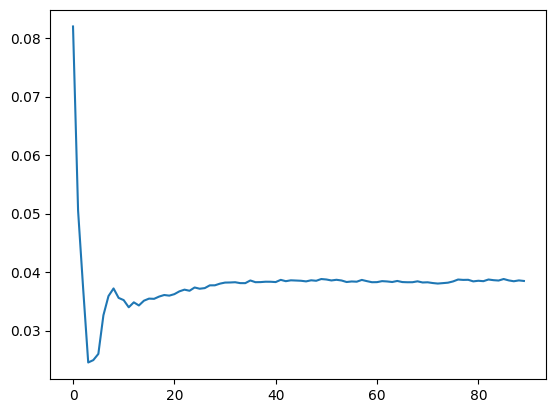

In [55]:
results_1.plot()

In [15]:
# Save instructions

# save modelname.sate_dict() as follows, save name as .pt file 
torch.save(pred_model.state_dict(), "pred_model1.pt")

In [28]:
# get units to load model
def load_units(session, scan_idx, directory = None):
    load = lambda f: f(session, scan_idx, directory)
    return load


In [ ]:
# Load instructions 

# make sure to instantiate new Visual model
from fnn.microns.build import network

pred_model2 = network()
pred_model2.load_state_dict(torch.load("pred_model1.pt", weights_only = True))
pred_model2.eval()


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'function'

In [14]:
# test prediction

frames = concatenate([
    full(shape=[30, 144, 256], dtype="uint8", fill_value=0),   # 1 second of black
    full(shape=[30, 144, 256], dtype="uint8", fill_value=128), # 1 second of gray
    full(shape=[30, 144, 256], dtype="uint8", fill_value=255), # 1 second of white
])

pred_model2.predict(frames)

array([[2.8345187 , 0.37566426, 1.0214528 , ..., 0.11336629, 0.08315441,
        0.08279585],
       [2.5968683 , 0.3080063 , 1.1581903 , ..., 0.13637638, 0.09433875,
        0.10654334],
       [2.2537212 , 0.2620629 , 0.9872199 , ..., 0.15106675, 0.05480776,
        0.08437876],
       ...,
       [1.4840398 , 0.79370004, 0.92337143, ..., 0.14210643, 0.1046189 ,
        0.07030241],
       [1.4843011 , 0.79425985, 0.92369956, ..., 0.14194277, 0.10505286,
        0.07042978],
       [1.4840629 , 0.7947323 , 0.923661  , ..., 0.14179638, 0.10546393,
        0.07055773]], dtype=float32)